# Week 9 Phase 1.17A — Physics-Contour Geometry Audit

Diagnostic only: no new acquisition path and no M3 refit.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image, Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_17a_physics_contour_geometry_audit'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'all_paths_length_80': True,
 'all_paths_unique': True,
 'arms': ['M3_MARGIN',
  'REP_C025',
  'REP_C050',
  'REP_C100',
  'REP_C200',
  'REP_C400'],
 'conduction': 332,
 'current_head': '746b19153f377bb0b7219d1c113bab672e306b19',
 'exact_branch_base': '746b19153f377bb0b7219d1c113bab672e306b19',
 'historical_changes': [],
 'keyholes': 73,
 'outer_runs': 100,
 'path_rows': 48000,
 'paths': 600,
 'phase16_decision': 'REPULSION_MECHANISM_ONLY',
 'population': 405,
 'required_parent_sha': '746b19153f377bb0b7219d1c113bab672e306b19',
 'shared_initial_designs': 100,
 'status': 'PASS'}

## 1. Geometry being audited

Every selected query is compared with its nearest previously queried point in the exact outer-pool standardized `[P,VX,LS,ST]` coordinates used by Phase 1.16.

In [2]:
display(json.loads((OUT/'analysis_specification.json').read_text())); display(pd.read_csv(OUT/'geometry_component_summary.csv'))

{'active_query_budgets': [17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80],
 'arms': ['M3_MARGIN',
  'REP_C025',
  'REP_C050',
  'REP_C100',
  'REP_C200',
  'REP_C400'],
 'checkpoints': [24, 32, 40, 60, 80],
 'components': {'ST': 'e_ST e_ST^T dz',
  'normal': 'n_h n_h^T dz',
  'physical_tangent': 'dz-normal-ST'},
 'coordinates': {'features': ['P', 'VX', 'LS', 'ST'],
  'gradient_z_log_h': ['s_P/P', '-s_VX/(2 VX)', '-3 s_LS/(2 LS)', '0'],
  'nearest_neighbor': 'original standardized Euclidean metric',
  'scaler': 'StandardScaler fit on complete outer-training pool features'},
 'decision_categories': ['NORMAL_ESCAPE',
  'ST_NULLSPACE_ESCAPE',
  'TRUE_PHYSICS_TAN

,index,arm,c,r_N_mean,r_N_median,r_T_mean,r_T_median,r_ST_mean,r_ST_median,total_distance_mean,...,st_energy_mean,st_energy_median,B1_distance_mean,B1_distance_median,is_q20_like_mean,is_q20_like_median,is_q30_like_mean,is_q30_like_median,true_label_mean,true_label_median
0,0,M3_MARGIN,0.00,0.184281,0.093683,0.568127,0.608078,0.247593,0.121244,0.768455,...,0.171349,0.061998,0.822460,0.791413,0.687656,1.0,0.831406,1.0,0.420469,0.0
1,1,REP_C025,0.25,0.181683,0.092824,0.568715,0.611761,0.249602,0.127644,0.801180,...,0.184192,0.065826,0.833645,0.791413,0.674531,1.0,0.823125,1.0,0.413750,0.0
2,2,REP_C050,0.50,0.188035,0.093174,0.554959,0.598813,0.257006,0.130569,0.850397,...,0.208800,0.080263,0.853146,0.815913,0.650937,1.0,0.805312,1.0,0.402656,0.0
3,3,REP_C100,1.00,0.201188,0.101519,0.543098,0.573895,0.255714,0.133994,0.884129,...,0.225763,0.086642,0.871210,0.833768,0.629687,1.0,0.792344,1.0,0.399375,0.0
4,4,REP_C200,2.00,0.203225,0.103269,0.543997,0.574517,0.252778,0.133497,0.895954,...,0.229424,0.087207,0.876756,0.839258,0.623594,1.0,0.787500,1.0,0.397500,0.0
5,5,REP_C400,4.00,0.203491,0.103725,0.544539,0.574682,0.251971,0.133497,0.898344,...,0.229734,0.088194,0.878119,0.839258,0.621875,1.0,0.786563,1.0,0.397188,0.0


## 2. Scale response

Squared displacement is split into local physics-normal, P/VX/LS physics-tangent, and ST components.

,arm,c,mean_r_N,mean_r_T,mean_r_ST,mean_total_distance,mean_normal_energy,mean_tangent_energy,mean_st_energy,mean_B1_distance,q20_fraction,q30_fraction,keyhole_fraction
0,M3_MARGIN,0.00,0.184281,0.568127,0.247593,0.768455,0.127645,0.392806,0.171349,0.822460,0.687656,0.831406,0.420469
1,REP_C025,0.25,0.181683,0.568715,0.249602,0.801180,0.136823,0.419664,0.184192,0.833645,0.674531,0.823125,0.413750
2,REP_C050,0.50,0.188035,0.554959,0.257006,0.850397,0.159514,0.452038,0.208800,0.853146,0.650937,0.805312,0.402656
3,REP_C100,1.00,0.201188,0.543098,0.255714,0.884129,0.185366,0.469383,0.225763,0.871210,0.629687,0.792344,0.399375
4,REP_C200,2.00,0.203225,0.543997,0.252778,0.895954,0.191678,0.482305,0.229424,0.876756,0.623594,0.787500,0.397500
5,REP_C400,4.00,0.203491,0.544539,0.251971,0.898344,0.192987,0.485819,0.229734,0.878119,0.621875,0.786563,0.397188


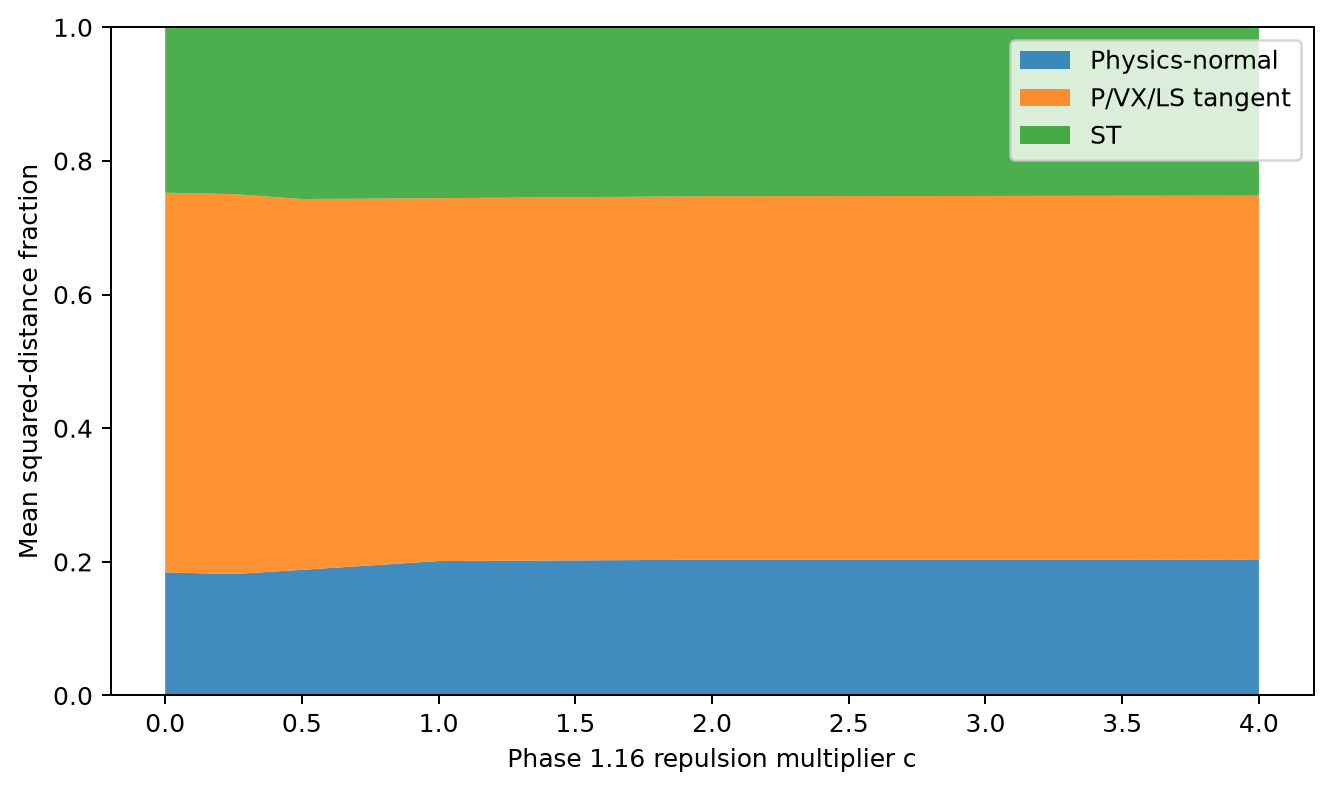

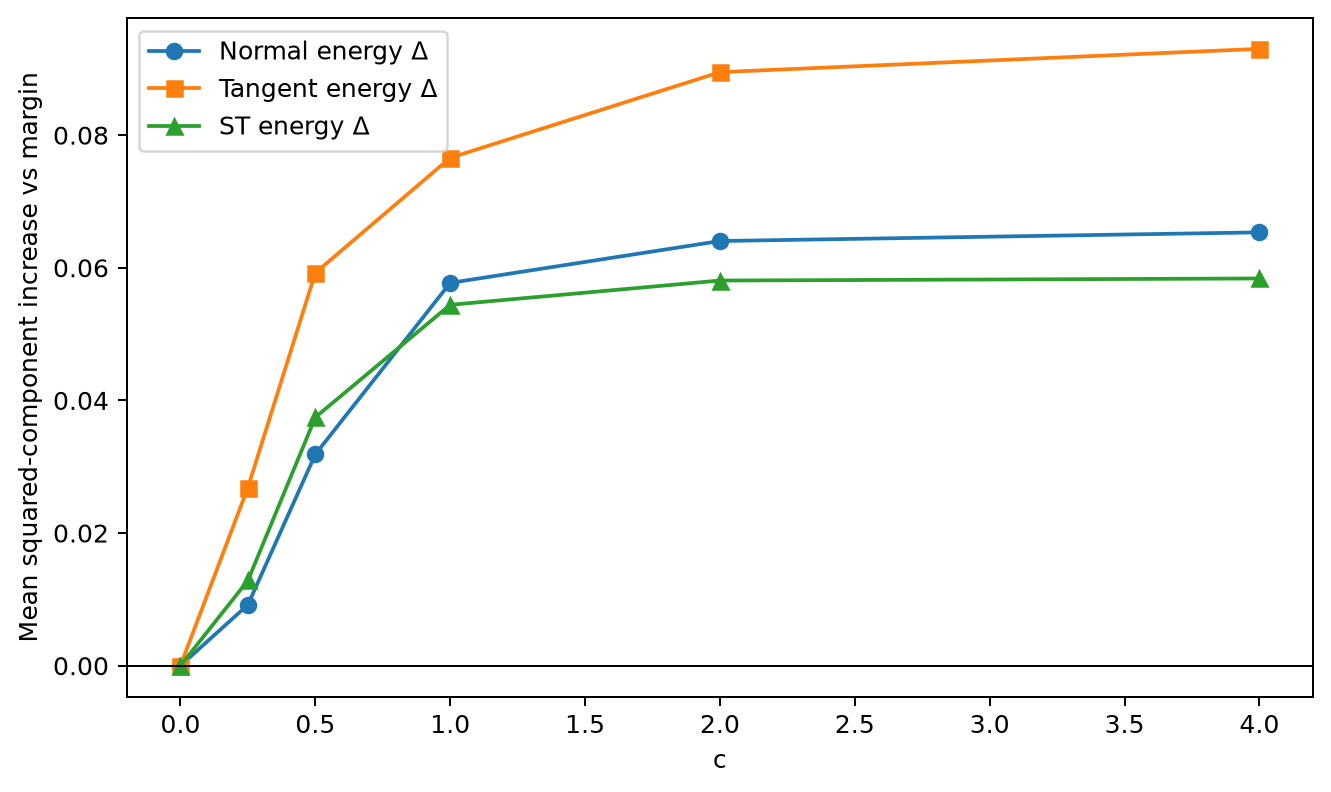

In [3]:
display(pd.read_csv(OUT/'scale_response_geometry.csv')); display(Image(filename=str(OUT/'figures'/'01_component_fractions_vs_scale.png'))); display(Image(filename=str(OUT/'figures'/'05_extra_distance_mechanism.png')))

## 3. Budget dependence

,arm,c,region,rows,mean_r_N,mean_r_T,mean_r_ST,mean_total_distance,mean_normal_energy,mean_tangent_energy,mean_st_energy,mean_B1_distance,q20_fraction,keyhole_fraction
0,M3_MARGIN,0.00,EARLY_B17_24,800,0.206151,0.543696,0.250153,1.055092,0.265809,0.672256,0.337559,0.763949,0.716250,0.478750
1,M3_MARGIN,0.00,LATE_B41_80,4000,0.190187,0.560943,0.248870,0.699290,0.109202,0.313900,0.125845,0.875955,0.633750,0.391250
2,M3_MARGIN,0.00,MID_B25_40,1600,0.158579,0.598302,0.243119,0.798050,0.104672,0.450347,0.202003,0.717978,0.808125,0.464375
3,REP_C025,0.25,EARLY_B17_24,800,0.196612,0.535195,0.268192,1.176840,0.304689,0.793016,0.411947,0.813779,0.693750,0.496250
4,REP_C025,0.25,LATE_B41_80,4000,0.188445,0.567671,0.243884,0.696092,0.107284,0.309793,0.126715,0.861654,0.630250,0.381750
5,REP_C025,0.25,MID_B25_40,1600,0.157314,0.588086,0.254600,0.876068,0.126737,0.507668,0.214007,0.773556,0.775625,0.452500
6,REP_C050,0.50,EARLY_B17_24,800,0.187788,0.538226,0.273986,1.289220,0.346496,0.938355,0.487401,0.834050,0.685000,0.476250
7,REP_C050,0.50,LATE_B41_80,4000,0.201339,0.542289,0.256372,0.728954,0.128457,0.311585,0.141461,0.874407,0.613500,0.372750
8,REP_C050,0.50,MID_B25_40,1600,0.154898,0.595001,0.250102,0.934595,0.143664,0.560014,0.237847,0.809541,0.727500,0.440625
9,REP_C100,1.00,EARLY_B17_24,800,0.203736,0.504256,0.292009,1.340128,0.411397,0.950199,0.550988,0.861249,0.643750,0.477500


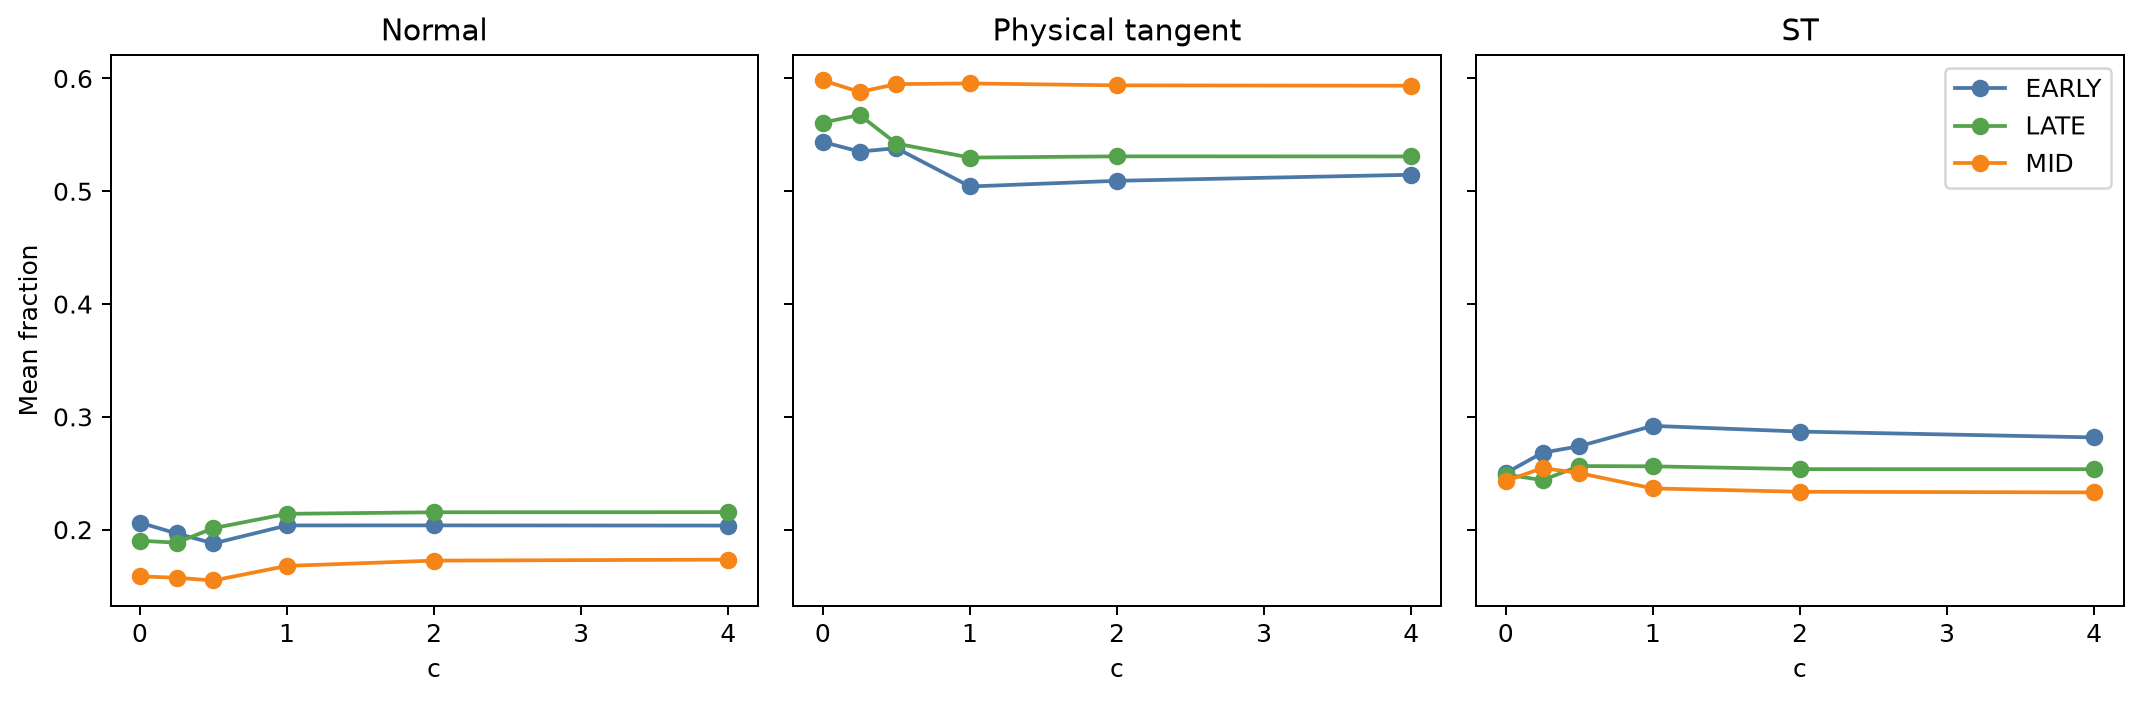

In [4]:
display(pd.read_csv(OUT/'budget_region_geometry.csv')); display(Image(filename=str(OUT/'figures'/'02_components_by_budget_region.png')))

## 4. Retrospective q20 and B1 diagnostics

These quantities were joined only after the geometry table was frozen.

,arm,c,group,rows,mean_r_N,mean_r_T,mean_r_ST,mean_total_distance,mean_B1_distance
0,M3_MARGIN,0.00,q20_like,4401,0.193259,0.587499,0.219242,0.726561,0.663151
1,M3_MARGIN,0.00,non_q20,1999,0.164514,0.525477,0.310009,0.860691,1.173195
2,M3_MARGIN,0.00,q20_like_minus_non_q20,6400,0.028744,0.062022,-0.090766,-0.134131,-0.510045
3,REP_C025,0.25,q20_like,4317,0.189935,0.589246,0.220819,0.754481,0.667328
4,REP_C025,0.25,non_q20,2083,0.164582,0.526164,0.309254,0.897963,1.178335
5,REP_C025,0.25,q20_like_minus_non_q20,6400,0.025353,0.063082,-0.088435,-0.143482,-0.511006
6,REP_C050,0.50,q20_like,4166,0.189137,0.582642,0.228221,0.797608,0.680756
7,REP_C050,0.50,non_q20,2234,0.185978,0.503336,0.310686,0.948839,1.174621
8,REP_C050,0.50,q20_like_minus_non_q20,6400,0.003159,0.079306,-0.082465,-0.151231,-0.493866
9,REP_C100,1.00,q20_like,4030,0.199864,0.571669,0.228467,0.823810,0.688758


,arm,c,region,component,association,candidate_rho,repeat_mean_rho,ci_lower,ci_upper,bottom_B1_quartile_mean,top_B1_quartile_mean,top_minus_bottom
18,M3_MARGIN,0.00,OVERALL_B17_80,r_N,spearman_vs_B1,-0.128857,-0.129555,-0.146153,-0.113454,NaN,NaN,NaN
19,M3_MARGIN,0.00,OVERALL_B17_80,r_N,B1_top_vs_bottom_quartile,NaN,NaN,NaN,NaN,0.230241,0.156075,-0.074166
20,M3_MARGIN,0.00,OVERALL_B17_80,r_T,spearman_vs_B1,-0.101896,-0.104093,-0.120357,-0.088508,NaN,NaN,NaN
21,M3_MARGIN,0.00,OVERALL_B17_80,r_T,B1_top_vs_bottom_quartile,NaN,NaN,NaN,NaN,0.613132,0.504230,-0.108902
22,M3_MARGIN,0.00,OVERALL_B17_80,r_ST,spearman_vs_B1,0.237914,0.238829,0.223679,0.252915,NaN,NaN,NaN
23,M3_MARGIN,0.00,OVERALL_B17_80,r_ST,B1_top_vs_bottom_quartile,NaN,NaN,NaN,NaN,0.156627,0.339696,0.183068
42,REP_C025,0.25,OVERALL_B17_80,r_N,spearman_vs_B1,-0.115789,-0.119174,-0.141619,-0.096832,NaN,NaN,NaN
43,REP_C025,0.25,OVERALL_B17_80,r_N,B1_top_vs_bottom_quartile,NaN,NaN,NaN,NaN,0.217282,0.158846,-0.058436
44,REP_C025,0.25,OVERALL_B17_80,r_T,spearman_vs_B1,-0.108780,-0.110289,-0.131038,-0.088498,NaN,NaN,NaN
45,REP_C025,0.25,OVERALL_B17_80,r_T,B1_top_vs_bottom_quartile,NaN,NaN,NaN,NaN,0.621369,0.521076,-0.100293


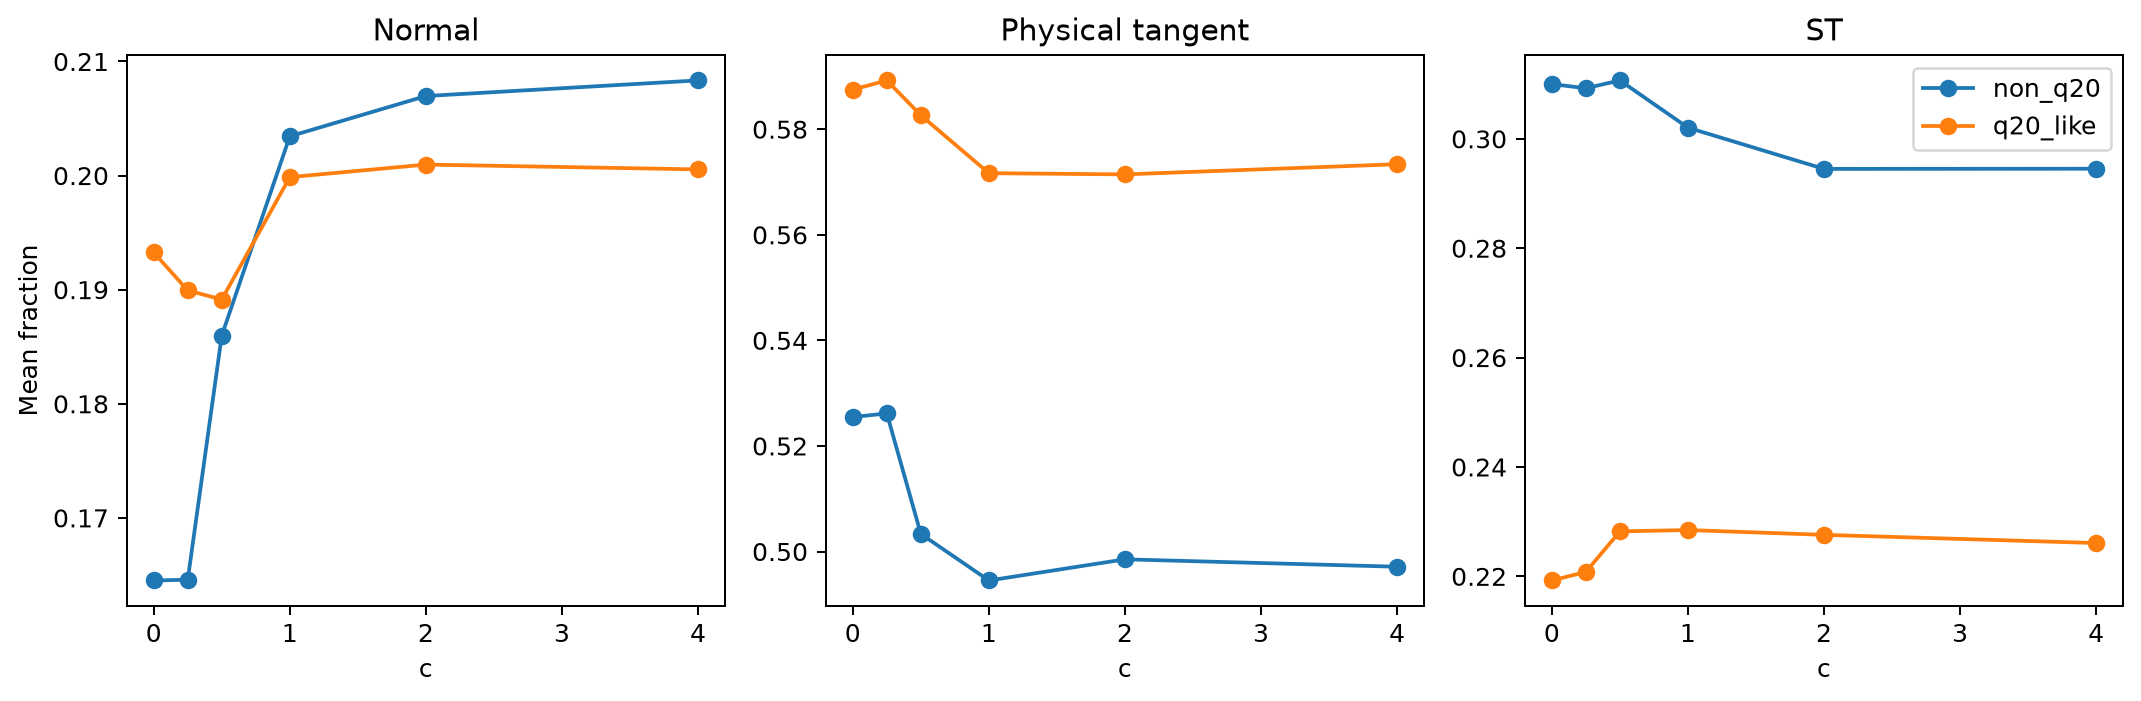

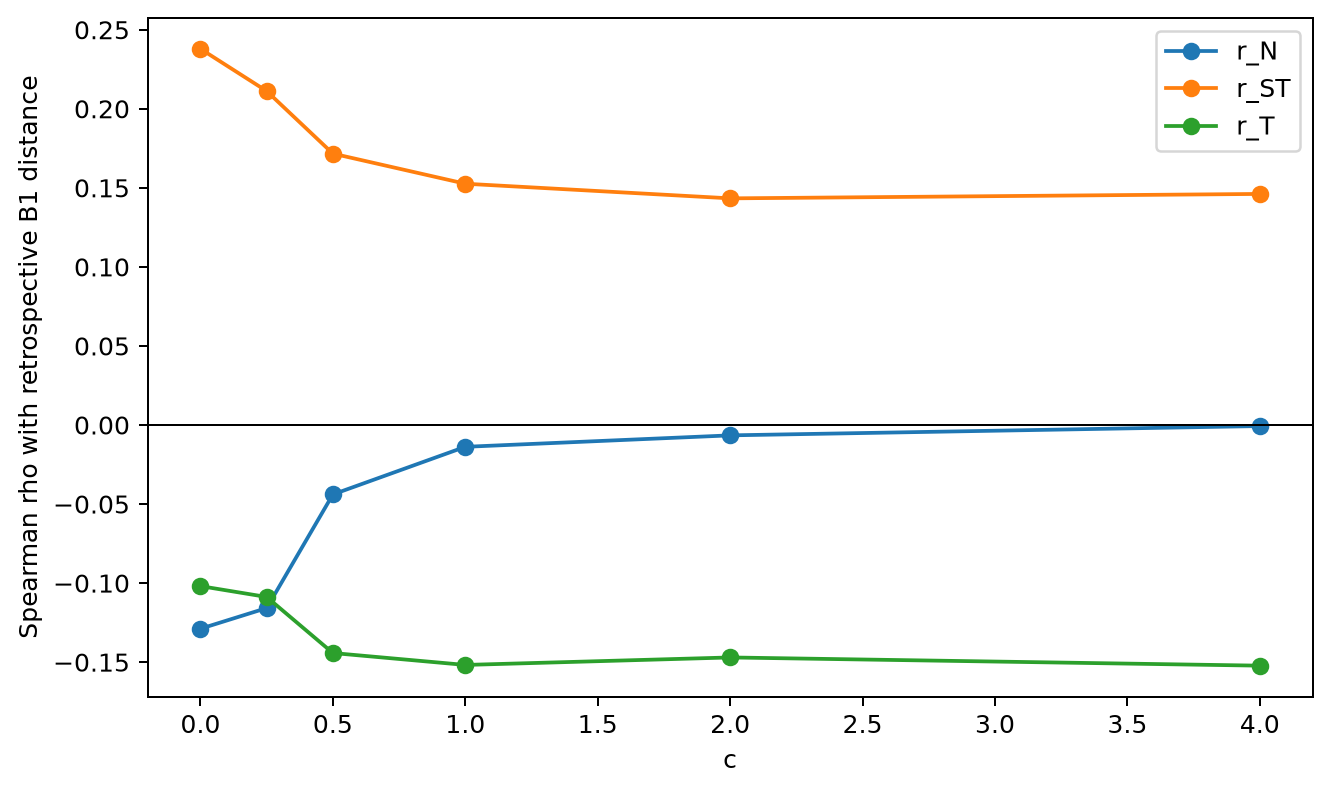

In [5]:
display(pd.read_csv(OUT/'q20_geometry_comparison.csv')); display(pd.read_csv(OUT/'b1_component_associations.csv').query("region=='OVERALL_B17_80'")); display(Image(filename=str(OUT/'figures'/'03_q20_component_comparison.png'))); display(Image(filename=str(OUT/'figures'/'04_B1_component_associations.png')))

## 5. Paired repeat-block inference

In [6]:
display(pd.read_csv(OUT/'repeat_block_inference.csv').query("scope=='OVERALL_B17_80'"))

,arm,c,scope,metric,delta_vs_M3_MARGIN,ci_lower,ci_upper,positive_repeat_blocks,zero_repeat_blocks,negative_repeat_blocks,bootstrap_draws
105,REP_C025,0.25,OVERALL_B17_80,r_N,-0.002597,-0.005357,0.000617,7,0,13,10000
106,REP_C050,0.50,OVERALL_B17_80,r_N,0.003754,0.000169,0.007638,11,0,9,10000
107,REP_C100,1.00,OVERALL_B17_80,r_N,0.016907,0.012425,0.021034,19,0,1,10000
108,REP_C200,2.00,OVERALL_B17_80,r_N,0.018944,0.014948,0.023155,20,0,0,10000
109,REP_C400,4.00,OVERALL_B17_80,r_N,0.019210,0.014931,0.023862,20,0,0,10000
110,REP_C025,0.25,OVERALL_B17_80,r_T,0.000588,-0.004396,0.005546,10,0,10,10000
111,REP_C050,0.50,OVERALL_B17_80,r_T,-0.013168,-0.018807,-0.007632,3,0,17,10000
112,REP_C100,1.00,OVERALL_B17_80,r_T,-0.025028,-0.030530,-0.018750,1,0,19,10000
113,REP_C200,2.00,OVERALL_B17_80,r_T,-0.024130,-0.030140,-0.017971,1,0,19,10000
114,REP_C400,4.00,OVERALL_B17_80,r_T,-0.023588,-0.030402,-0.016456,2,0,18,10000


## 6. Safe decision

In [7]:
display(json.loads((OUT/'mechanism_decision.json').read_text(encoding='utf-8'))); display(Markdown((OUT/'SUPERVISOR_PHASE1_17A_ONE_PAGE.md').read_text(encoding='utf-8')))

{'decision': 'MIXED_GEOMETRIC_MECHANISM',
 'flags': {'B1_distance_delta_c4': 0.05565885672954185,
  'c4_energy_delta': {'normal': 0.06534145455576637,
   'st': 0.05838554607497806,
   'tangent': 0.09301290870310996},
  'c4_positive_extra_energy_share': {'normal': 0.30147403289312047,
   'st': 0.26938068883771715,
   'tangent': 0.4291452782691624},
  'keyhole_fraction_delta_c4': -0.023281249999999976,
  'q20_fraction_delta_c4': -0.06578125000000001,
  'supported_share_increases': {'r_N': 4, 'r_ST': 3, 'r_T': 0},
  'total_distance_delta_c4': 0.12988877733845805},
 'predeclared_categories': ['NORMAL_ESCAPE',
  'ST_NULLSPACE_ESCAPE',
  'TRUE_PHYSICS_TANGENT_SPREAD',
  'MIXED_GEOMETRIC_MECHANISM',
  'NO_CLEAR_GEOMETRIC_MECHANISM']}

# Supervisor Phase 1.17A one-page

**Decision: MIXED_GEOMETRIC_MECHANISM**

- Diagnostic only: 38,400 already-selected Phase 1.16 queries; no new model fit or trajectory.
- c=0 fractions: normal 0.184, P/VX/LS tangent 0.568, ST 0.248.
- c=4 fractions: normal 0.203, tangent 0.545, ST 0.252.
- Positive extra squared-distance contribution at c=4: normal 30.1%, tangent 42.9%, ST 26.9%.
- B1 distance Δ +0.056; q20-query fraction Δ -0.066; Keyhole-query fraction Δ -0.023.
- At c=4, B1 distance is associated with ST share (ρ=+0.145) and inversely with tangent share (ρ=-0.151); normal association is unresolved.
- The pattern changes by budget: early ST, mid mixed, late normal-share increase.
- ST is not declared physically irrelevant; this is standardized-space geometry.
- Physics contours are not claimed to be the true M3 decision boundary.
- Recommendation: do not run Phase 1.17B now; no single harmful mechanism is isolated that tangent-only PCTR specifically removes.
